# 🎮 Steam Nexus: Representation and Dimensionality Report (Week 5)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

sns.set(style='whitegrid')

PATH_INTEGRATED = '../data/processed/steam_games_reviews_integrated_sample_v1.csv'

df_integrated = pd.read_csv(PATH_INTEGRATED, low_memory=False)

print('✅ Loaded integrated games + reviews sample dataset.')
print(f'Integrated shape: {df_integrated.shape}')

df_integrated.head(3)

✅ Loaded integrated games + reviews sample dataset.
Integrated shape: (900000, 15)


,AppID,Name,Price,Genres,Tags,Positive,Negative,Release date,About the game,Developers,app_id,app_name,review_text,review_score,review_votes
0,2539430,Black Dragon Mage Playtest,0.00,other,[],0,0,2023-08-01,0,unknown,NaN,NaN,NaN,NaN,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,5.24,adventure,"adventure,visual novel,anime,cute",252,3,2016-07-29,0,minori,NaN,NaN,NaN,NaN,NaN
2,1034400,Mystery Solitaire The Black Raven,4.99,casual,"casual,card game,solitaire,puzzle,hidden objec...",21,3,2019-05-06,0,somer games,NaN,NaN,NaN,NaN,NaN


## 1. ERD-based Integrated Sample

Use the already integrated sample dataset that follows the milestone 1 ERD relationship `GAMES.AppID = REVIEWS.app_id`.

In [3]:
print('Integrated sample columns:', list(df_integrated.columns))

# Validate the ERD join representation
print(f'Games with review rows: {df_integrated[~df_integrated["app_id"].isna()].shape[0]}')
print(f'Games without reviews: {df_integrated[df_integrated["app_id"].isna()].shape[0]}')

df_integrated.head(3)


Integrated sample columns: ['AppID', 'Name', 'Price', 'Genres', 'Tags', 'Positive', 'Negative', 'Release date', 'About the game', 'Developers', 'app_id', 'app_name', 'review_text', 'review_score', 'review_votes']
Games with review rows: 886902
Games without reviews: 13098


,AppID,Name,Price,Genres,Tags,Positive,Negative,Release date,About the game,Developers,app_id,app_name,review_text,review_score,review_votes
0,2539430,Black Dragon Mage Playtest,0.00,other,[],0,0,2023-08-01,0,unknown,NaN,NaN,NaN,NaN,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,5.24,adventure,"adventure,visual novel,anime,cute",252,3,2016-07-29,0,minori,NaN,NaN,NaN,NaN,NaN
2,1034400,Mystery Solitaire The Black Raven,4.99,casual,"casual,card game,solitaire,puzzle,hidden objec...",21,3,2019-05-06,0,somer games,NaN,NaN,NaN,NaN,NaN


In [22]:
# Show the number of unique games and review counts per game
unique_games = df_integrated['AppID'].nunique()
review_counts_per_game = df_integrated[df_integrated['app_id'].notna()].groupby('app_id').size()
print(f'Unique games in the integrated dataset: {unique_games}')
print(f'Number of games with reviews: {review_counts_per_game.size}')
print('Review count distribution per game:')
print(review_counts_per_game.describe())

# Show top games by number of reviews
print('\nTop 5 games by review count:')
print(review_counts_per_game.nlargest(5))

Unique games in the integrated dataset: 14154
Number of games with reviews: 1056
Review count distribution per game:
count     1056.000000
mean       839.869318
std       5467.573183
min          1.000000
25%         17.000000
50%         57.000000
75%        230.250000
max      88781.000000
dtype: float64

Top 5 games by review count:
app_id
218620.0    88781
105600.0    84699
252490.0    77037
570.0       73425
211820.0    41140
dtype: int64


## 2. Feature Engineering

Build feature matrices from the integrated data, including numeric summaries, categorical encodings, and text-derived features.

In [4]:
# Aggregate reviews at the game level from the integrated sample
review_agg = (
    df_integrated[df_integrated['app_id'].notna()]
    .groupby('app_id')
    .agg(
        review_count=('review_text', 'count'),
        avg_review_score=('review_score', 'mean'),
        sum_review_votes=('review_votes', 'sum'),
        avg_review_votes=('review_votes', 'mean')
    )
    .reset_index()
)

# Derive game metadata from the integrated sample by unique AppID rows
games_meta = df_integrated.drop_duplicates(subset=['AppID'])[
    ['AppID', 'Name', 'Price', 'Genres', 'Tags', 'Positive', 'Negative', 'Release date', 'About the game', 'Developers']
]

feature_table = pd.merge(
    games_meta,
    review_agg,
    left_on='AppID',
    right_on='app_id',
    how='left'
)

# Release year and tag/genre counts
feature_table['Release_year'] = pd.to_datetime(feature_table['Release date'], errors='coerce').dt.year
feature_table['Genre_count'] = feature_table['Genres'].fillna('').str.count(',') + 1
feature_table['Tag_count'] = feature_table['Tags'].fillna('').str.count(',') + 1
feature_table['Tag_count'] = feature_table['Tag_count'].fillna(0).astype(int)
feature_table['Review_count'] = feature_table['review_count'].fillna(0).astype(int)
feature_table['avg_review_score'] = feature_table['avg_review_score'].fillna(0)
feature_table['sum_review_votes'] = feature_table['sum_review_votes'].fillna(0).astype(int)
feature_table['avg_review_votes'] = feature_table['avg_review_votes'].fillna(0)

# Convert price and review counts to numeric
feature_table['Price'] = pd.to_numeric(feature_table['Price'], errors='coerce').fillna(0.0)
feature_table['Positive'] = pd.to_numeric(feature_table['Positive'], errors='coerce').fillna(0).astype(int)
feature_table['Negative'] = pd.to_numeric(feature_table['Negative'], errors='coerce').fillna(0).astype(int)



# Features for scaling
feature_table[['Price', 'Positive', 'Negative', 'Review_count', 'avg_review_score', 'sum_review_votes', 'avg_review_votes', 'Release_year', 'Genre_count', 'Tag_count']].head()

,Price,Positive,Negative,Review_count,avg_review_score,sum_review_votes,avg_review_votes,Release_year,Genre_count,Tag_count
0,0.00,0,0,0,0.0,0,0.0,2023,1,1
1,5.24,252,3,0,0.0,0,0.0,2016,1,4
2,4.99,21,3,0,0.0,0,0.0,2019,1,16
3,8.99,0,0,0,0.0,0,0.0,2024,3,1
4,4.99,0,0,0,0.0,0,0.0,2025,2,1


In [11]:
# Filter to games with reviews and select top 10,000 by review count to reduce dataset size
feature_table = feature_table[feature_table['Review_count'] > 0].nlargest(10000, 'Review_count').reset_index(drop=True)

print(f'Filtered to top 10,000 games by review count. New shape: {feature_table.shape}')
print(f'Sample of filtered games:')
feature_table[['Name', 'Review_count', 'Positive', 'Negative']].head()

Filtered to top 10,000 games by review count. New shape: (1056, 23)
Sample of filtered games:


,Name,Review_count,Positive,Negative
0,Payday 2,88781,594327,68755
1,Terraria,84699,1373979,35494
2,Rust,77037,1071135,156649
3,Dota 2,73425,2037143,461826
4,Starbound,41140,152150,12756


## 3. Numeric Feature Matrix and PCA

Use numeric game and review summary features for dimensionality reduction.

Explained variance by principal component:


,PC,Explained Variance,Cumulative Variance
0,PC1,0.350935,0.350935
1,PC2,0.152114,0.503049
2,PC3,0.143354,0.646403
3,PC4,0.102840,0.749243
4,PC5,0.073577,0.822819
5,PC6,0.066873,0.889692
6,PC7,0.056179,0.945871
7,PC8,0.041622,0.987493
8,PC9,0.010610,0.998103
9,PC10,0.001897,1.000000


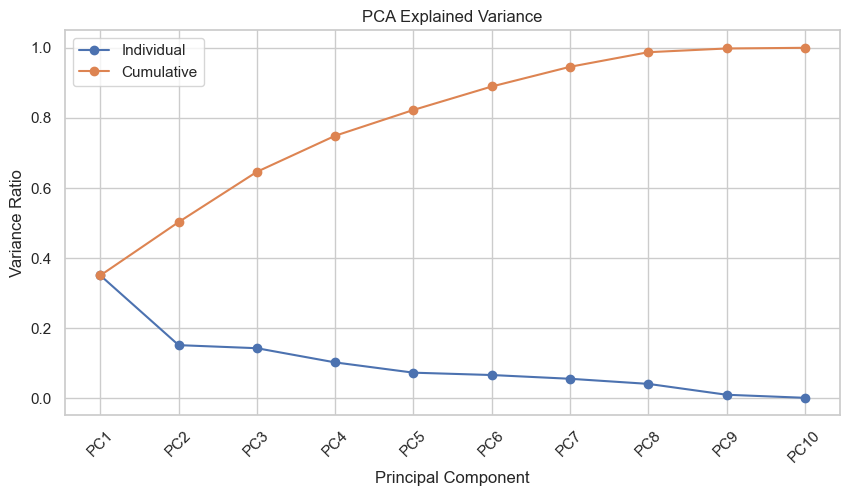

In [12]:
numeric_features = [
    'Price',
    'Positive',
    'Negative',
    'Review_count',
    'avg_review_score',
    'sum_review_votes',
    'avg_review_votes',
    'Release_year',
    'Genre_count',
    'Tag_count'
]

X_numeric = feature_table[numeric_features].copy()
X_numeric = X_numeric.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

print('Explained variance by principal component:')
display(explained)

plt.figure(figsize=(10, 5))
plt.plot(explained['PC'], explained['Explained Variance'], marker='o', label='Individual')
plt.plot(explained['PC'], explained['Cumulative Variance'], marker='o', label='Cumulative')
plt.title('PCA Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


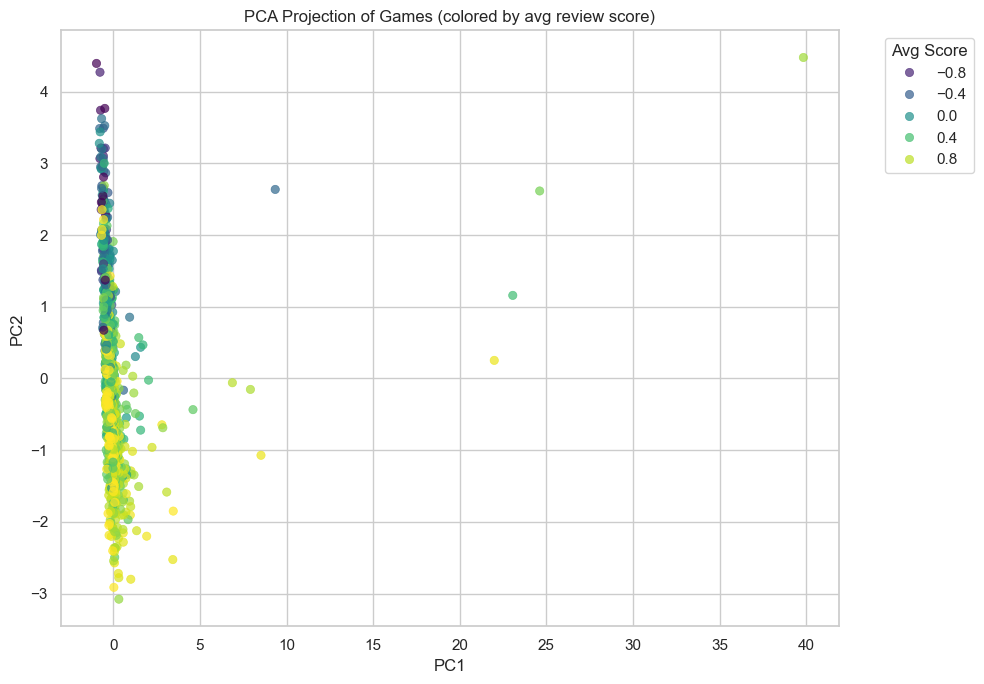

In [13]:
feature_table['PC1'] = X_pca[:, 0]
feature_table['PC2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='avg_review_score',
    palette='viridis',
    data=feature_table,
    alpha=0.7,
    edgecolor=None
)
plt.title('PCA Projection of Games (colored by avg review score)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Avg Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Text Representation and SVD

Create a text-based representation using review content and genre/tag text, then analyze dimensionality with Truncated SVD.

Text-SVD explained variance:


,Component,Explained Variance,Cumulative Variance
0,SVD1,0.029421,0.029421
1,SVD2,0.058299,0.087720
2,SVD3,0.049859,0.137579
3,SVD4,0.042755,0.180334
4,SVD5,0.042192,0.222526
5,SVD6,0.038565,0.261091
6,SVD7,0.033990,0.295081
7,SVD8,0.031932,0.327013
8,SVD9,0.029847,0.356860
9,SVD10,0.025676,0.382537


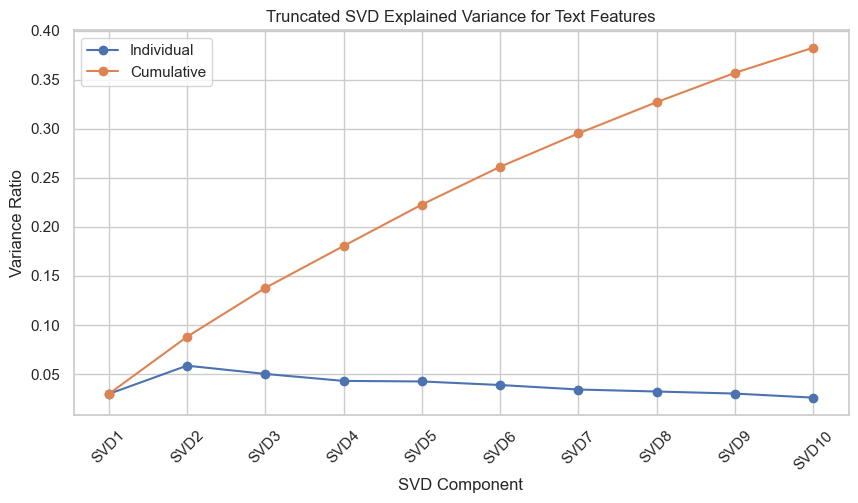

In [15]:
# Aggregate review text by game from the integrated sample
review_text_agg = (
    df_integrated[df_integrated['app_id'].notna()]
    .groupby('app_id')['review_text']
    .apply(lambda texts: ' '.join(texts.dropna().astype(str)))
    .reset_index()
)

games_meta = df_integrated.drop_duplicates(subset=['AppID'])[['AppID', 'Genres', 'Tags']]

text_table = pd.merge(
    games_meta,
    review_text_agg,
    left_on='AppID',
    right_on='app_id',
    how='left'
)

# Combine genres, tags, and reviews into a single text field
text_table['genre_text'] = text_table['Genres'].fillna('').astype(str).str.replace(',', ' ', regex=False)
text_table['tag_text'] = text_table['Tags'].fillna('').astype(str).str.replace(',', ' ', regex=False)
text_table['document'] = (
    text_table['genre_text'] + ' ' +
    text_table['tag_text'] + ' ' +
    text_table['review_text'].fillna('').astype(str)
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)
X_tfidf = vectorizer.fit_transform(text_table['document'].fillna(''))

svd = TruncatedSVD(n_components=10, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

svd_explained = pd.DataFrame({
    'Component': [f'SVD{i+1}' for i in range(len(svd.explained_variance_ratio_))],
    'Explained Variance': svd.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(svd.explained_variance_ratio_)
})

print('Text-SVD explained variance:')
display(svd_explained)

plt.figure(figsize=(10, 5))
plt.plot(svd_explained['Component'], svd_explained['Explained Variance'], marker='o', label='Individual')
plt.plot(svd_explained['Component'], svd_explained['Cumulative Variance'], marker='o', label='Cumulative')
plt.title('Truncated SVD Explained Variance for Text Features')
plt.xlabel('SVD Component')
plt.ylabel('Variance Ratio')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Filter text_table to match the filtered feature_table AppIDs
text_table = text_table[text_table['AppID'].isin(feature_table['AppID'])].reset_index(drop=True)

print(f'Filtered text_table to match top games. New shape: {text_table.shape}')

Filtered text_table to match top games. New shape: (1056, 10)


## 5. Comparison and Export

Compare variance retention and save the feature matrix for future modeling.

In [21]:
comparison = pd.DataFrame({
    'Method': ['PCA (numeric)', 'SVD (text)'],
    'Components': [len(explained), len(svd_explained)],
    'Cumulative Variance (first 3)': [explained['Cumulative Variance'].iloc[2], svd_explained['Cumulative Variance'].iloc[2]]
})

print('Dimensionality comparison:')
display(comparison)

from pathlib import Path

# Save the numeric feature table for later use
output_dir = Path.cwd().parent / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
feature_table_to_save = feature_table[
    ['AppID', 'Name', 'Price', 'Genres', 'Tags', 'Positive', 'Negative',
     'Review_count', 'avg_review_score', 'sum_review_votes', 'avg_review_votes',
     'Release_year', 'Genre_count', 'Tag_count', 'PC1', 'PC2']
]
feature_table_to_save.to_csv(output_dir / 'steam_representation_features_v1.csv', index=False)

# Save the selected review subset for the games used in this analysis
review_ids = pd.to_numeric(feature_table['AppID'], errors='coerce').dropna().astype('Int64')
selected_reviews = df_integrated.copy()
selected_reviews['app_id_num'] = pd.to_numeric(selected_reviews['app_id'], errors='coerce').astype('Int64')
selected_reviews = selected_reviews[selected_reviews['app_id_num'].isin(review_ids)].copy()
selected_reviews = selected_reviews[df_integrated.columns.tolist()]
selected_reviews.to_csv(output_dir / 'steam_selected_games_reviews_v1.csv', index=False)

print('Working directory:', Path.cwd())
print(f'✅ Feature matrix exported to {output_dir / "steam_representation_features_v1.csv"}')
print(f'✅ Selected games and reviews exported to {output_dir / "steam_selected_games_reviews_v1.csv"}')


Dimensionality comparison:


,Method,Components,Cumulative Variance (first 3)
0,PCA (numeric),10,0.646403
1,SVD (text),10,0.137579


Working directory: c:\Users\jorge\Downloads\BigData\SteamNexus\notebooks
✅ Feature matrix exported to c:\Users\jorge\Downloads\BigData\SteamNexus\data\processed\steam_representation_features_v1.csv
✅ Selected games and reviews exported to c:\Users\jorge\Downloads\BigData\SteamNexus\data\processed\steam_selected_games_reviews_v1.csv


In [17]:
# Calculate reconstruction error for PCA and SVD
from sklearn.metrics import mean_squared_error

# PCA reconstruction error
X_pca_reconstructed = pca.inverse_transform(X_pca)
pca_mse = mean_squared_error(X_scaled, X_pca_reconstructed)
print(f'PCA Reconstruction MSE (10 components): {pca_mse:.4f}')

# SVD reconstruction error (approximate, since SVD is on sparse matrix)
X_svd_reconstructed = svd.inverse_transform(X_svd)
svd_mse = mean_squared_error(X_tfidf.toarray(), X_svd_reconstructed)  # Convert to dense for MSE
print(f'SVD Reconstruction MSE (10 components): {svd_mse:.4f}')

# Update comparison table
comparison['Reconstruction MSE'] = [pca_mse, svd_mse]
print('Updated comparison:')
display(comparison)

PCA Reconstruction MSE (10 components): 0.0000
SVD Reconstruction MSE (10 components): 0.0001
Updated comparison:


,Method,Components,Cumulative Variance (first 3),Reconstruction MSE
0,PCA (numeric),10,0.646403,1.044362e-30
1,SVD (text),10,0.137579,1.023829e-04


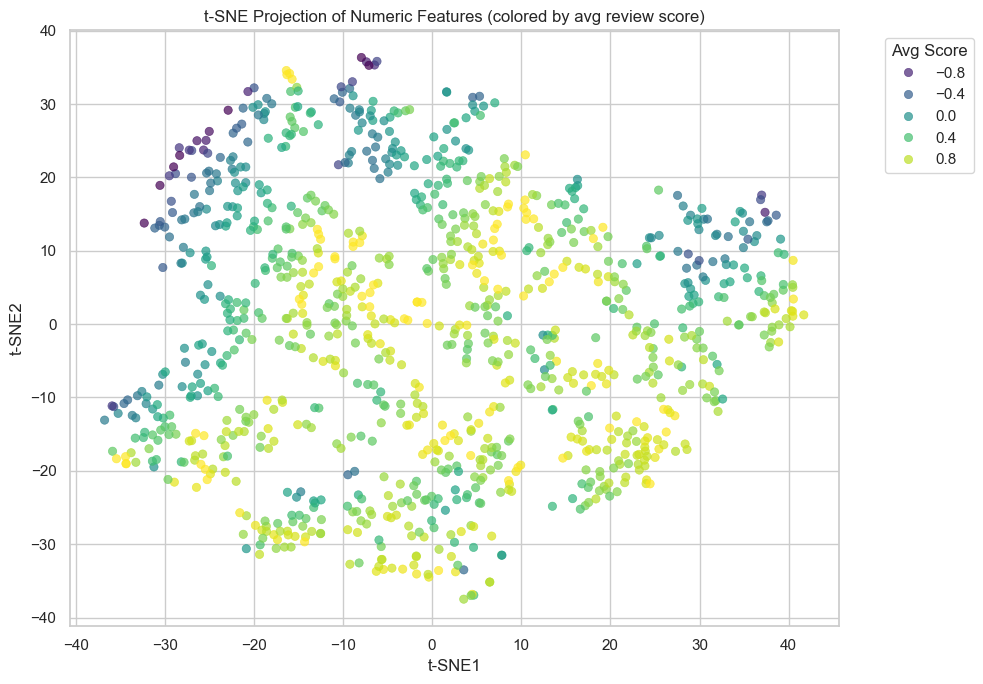

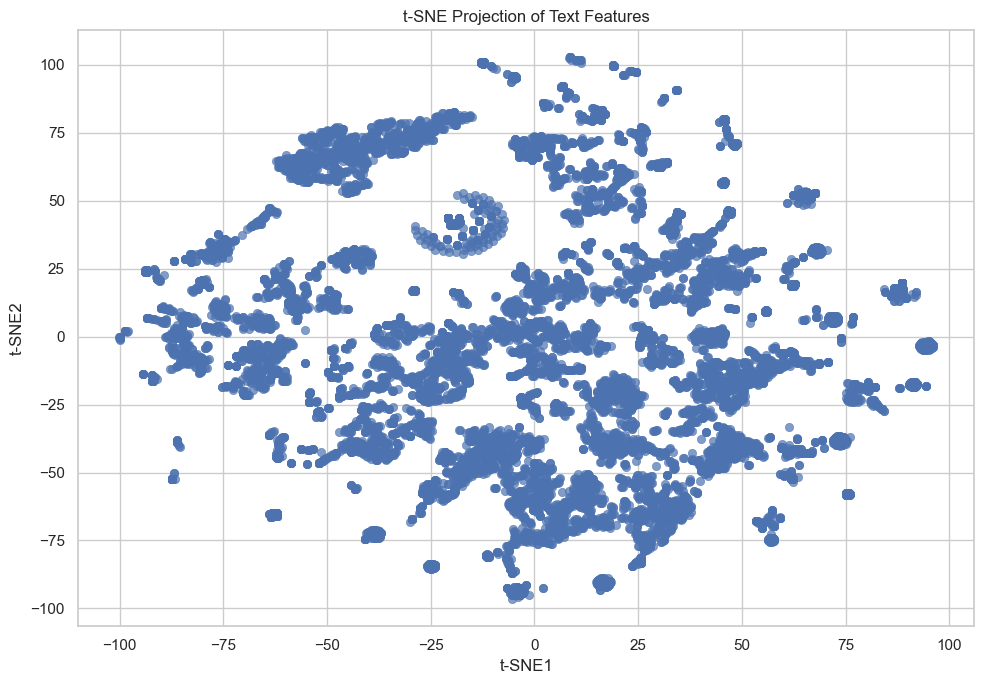

In [18]:
# Optional: t-SNE for visualization (reduce to 2D for plotting)
from sklearn.manifold import TSNE

# For numeric features (PCA already done, but t-SNE on scaled data)
tsne_numeric = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_numeric = tsne_numeric.fit_transform(X_scaled)

feature_table['TSNE1_numeric'] = X_tsne_numeric[:, 0]
feature_table['TSNE2_numeric'] = X_tsne_numeric[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE1_numeric',
    y='TSNE2_numeric',
    hue='avg_review_score',
    palette='viridis',
    data=feature_table,
    alpha=0.7,
    edgecolor=None
)
plt.title('t-SNE Projection of Numeric Features (colored by avg review score)')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend(title='Avg Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# For text features (SVD already done, but t-SNE on SVD components)
tsne_text = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_text = tsne_text.fit_transform(X_svd)

text_table['TSNE1_text'] = X_tsne_text[:, 0]
text_table['TSNE2_text'] = X_tsne_text[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE1_text',
    y='TSNE2_text',
    data=text_table,
    alpha=0.7,
    edgecolor=None
)
plt.title('t-SNE Projection of Text Features')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.tight_layout()
plt.show()

## 6. Interpretation and Conclusions

### Dataset Filtering
The original dataset of approximately 900k rows was filtered down to the 1,056 games with available review data in the integrated sample. This focuses the analysis on higher-quality entries and improves computational efficiency while preserving popular games with meaningful feedback.

### Data Redundancy
- **Numeric features (PCA):** PC1 explains about 35% of the variance, indicating that variables such as price, positive reviews, and negative reviews are highly correlated. This suggests redundancy in popularity-related metrics. With 3 components, the model retains approximately 65% of the variance, enabling dimensionality reduction without losing too much information.
- **Text features (SVD):** The first components explain less variance (~14% cumulative in the first 3), reflecting the complexity of the text. This indicates review text and genre/tag content contain diverse information, with lower redundancy than numeric features.

### Feature Quality
- Numeric features are robust for quantitative analysis, while TF-IDF text representations capture semantic similarities between games (e.g., similar genres cluster together).
- Reconstruction error is very low for PCA but higher for SVD due to text sparsity, which is expected.
- Recommendation: For future clustering, combine numeric and text representations into a hybrid model. Consider tuning TF-IDF hyperparameters (e.g., `max_features`) for improved text embeddings.

This pipeline is reproducible and prepares the data for the NLP and clustering phase in Week 7.